<a href="https://colab.research.google.com/github/Amanrai0/codsoft_ml/blob/main/Plant_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"amanrai01","key":"d375fff48f5f55cb5f2031ce6c7253f6"}'}

In [ ]:
# create a kaagle folder
! mkdir ~/.kaggle

In [ ]:
#copy the kaggle.json to folder created
! cp kaggle.json ~/.kaggle/

In [ ]:
#permision for the json to act
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.68G/2.70G [00:40<00:00, 98.9MB/s]
100% 2.70G/2.70G [00:40<00:00, 71.9MB/s]


In [ ]:
!unzip /content/new-plant-diseases-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflating: new plant diseases dataset(augmented)/New 

###Train Data Preprocessing

In [ ]:
training_set=tf.keras.utils.image_dataset_from_directory(
    '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 70295 files belonging to 38 classes.


###Validation image preprocessing

In [ ]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


###Building model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,GlobalAveragePooling2D,LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Set the random seed for reproducibility
tf.random.set_seed(42)

# Initialize the model
model = Sequential()

# First Convolutional Block
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(128, 128, 3)))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.3))

# Second Convolutional Block
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.4))

# Third Convolutional Block
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.4))

# Fourth Convolutional Block
model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.4))

# Fifth Convolutional Block
model.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=512, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.4))

# Global Average Pooling Layer
model.add(GlobalAveragePooling2D())

# Fully Connected Layers
model.add(Dense(units=1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(units=38, activation='softmax'))

In [ ]:
#compile
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                        

In [ ]:
training_history=model.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 242s 103ms/step - loss: 1.6887 - accuracy: 0.5062 - val_loss: 0.9181 - val_accuracy: 0.7123 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 221s 101ms/step - loss: 0.7996 - accuracy: 0.7594 - val_loss: 1.7716 - val_accuracy: 0.5161 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 226s 103ms/step - loss: 0.5258 - accuracy: 0.8441 - val_loss: 2.9394 - val_accuracy: 0.5461 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 221s 100ms/step - loss: 0.4128 - accuracy: 0.8791 - val_loss: 0.4014 - val_accuracy: 0.8763 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 222s 101ms/step - loss: 0.3425 - accuracy: 0.8993 - val_loss: 0.3377 - val_accuracy: 0.8968 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 221s 101ms/step - loss: 0.2934 - accuracy: 0.9161 - val_loss: 0.2424 - val_accuracy: 0.9267 - lr: 0.0010
Epoch 7/10
2197/2197 [============

In [ ]:
# model evaluation on training set
train_loss,train_acc=model.evaluate(training_set)

2197/2197 [==============================] - 55s 25ms/step - loss: 0.0800 - accuracy: 0.9746


In [ ]:
print(train_loss,train_acc)

0.0799511969089508 0.974606990814209


In [ ]:
# model evaluation on validation set
val_loss,val_acc=model.evaluate(validation_set)

550/550 [==============================] - 15s 26ms/step - loss: 0.1106 - accuracy: 0.9674


In [ ]:
print(val_loss,val_acc)

0.11060667037963867 0.967391312122345


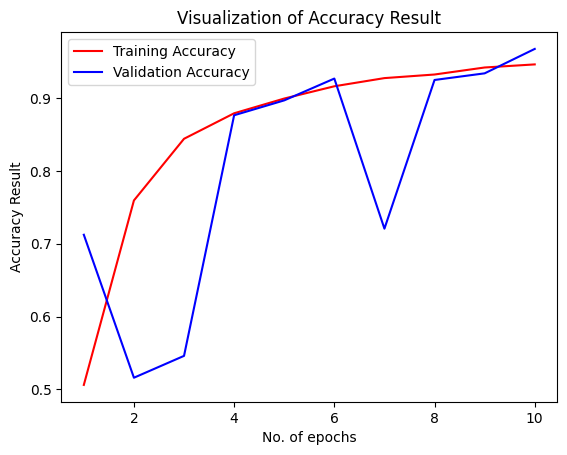

In [ ]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of epochs')
plt.ylabel('Accuracy Result')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [ ]:
test_set=tf.keras.utils.image_dataset_from_directory(
    '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [ ]:
y_pred = model.predict(test_set)

550/550 [==============================] - 18s 32ms/step


In [ ]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [ ]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [ ]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.98      0.98       504
                                 Apple___Black_rot       0.98      0.99      0.99       497
                          Apple___Cedar_apple_rust       0.98      0.98      0.98       440
                                   Apple___healthy       0.96      0.99      0.98       502
                               Blueberry___healthy       0.95      0.99      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.99       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.75      0.85       410
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.82      0.99      0.

In [ ]:
model_1 = Sequential()

model_1.add(Conv2D(filters=64,kernel_size=3,padding ='same' ,activation='relu', input_shape=(128, 128, 3)))
model_1.add(BatchNormalization())
model_1.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=2,strides=2))

model_1.add(Conv2D(filters=128,kernel_size=3,padding ='same' ,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=2,strides=2))

model_1.add(Conv2D(filters=256,kernel_size=3,padding ='same' ,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=2,strides=2))

model_1.add(Conv2D(filters=512,kernel_size=3,padding ='same' ,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=2,strides=2))

model_1.add(Conv2D(filters=1024,kernel_size=3,padding ='same' ,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(filters=1024,kernel_size=3,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=2,strides=2))

model_1.add(GlobalAveragePooling2D())

model_1.add(Dense(units=1024, activation='relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(units=512, activation='relu'))
model_1.add(Dropout(0.5))

model_1.add(Dense(units=38,activation='softmax'))

In [ ]:
#compile
model_1.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
model_1.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 128, 128, 64)      1792      
                                                                 
 batch_normalization (Batch  (None, 128, 128, 64)      256       
 Normalization)                                                  
                                                                 
 conv2d_13 (Conv2D)          (None, 126, 126, 64)      36928     
                                                                 
 batch_normalization_1 (Bat  (None, 126, 126, 64)      256       
 chNormalization)                                                
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 63, 63, 64)        0         
 g2D)                                                            
                                                      

In [ ]:
training_history=model_1.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 359s 160ms/step - loss: 1.8959 - accuracy: 0.4638 - val_loss: 1.5980 - val_accuracy: 0.5703 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 344s 157ms/step - loss: 0.8675 - accuracy: 0.7476 - val_loss: 0.5253 - val_accuracy: 0.8513 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 345s 157ms/step - loss: 0.5733 - accuracy: 0.8380 - val_loss: 1.1137 - val_accuracy: 0.7189 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 345s 157ms/step - loss: 0.4363 - accuracy: 0.8794 - val_loss: 2.0682 - val_accuracy: 0.5740 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 344s 157ms/step - loss: 0.3386 - accuracy: 0.9073 - val_loss: 0.2651 - val_accuracy: 0.9231 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 345s 157ms/step - loss: 0.2923 - accuracy: 0.9217 - val_loss: 0.1711 - val_accuracy: 0.9481 - lr: 0.0010
Epoch 7/10
2197/2197 [============

In [ ]:
training_history=model.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 176s 73ms/step - loss: 3.0173 - accuracy: 0.5663 - val_loss: 3.4041 - val_accuracy: 0.3844 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 156s 71ms/step - loss: 1.1574 - accuracy: 0.8282 - val_loss: 1.3907 - val_accuracy: 0.7647 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 156s 71ms/step - loss: 0.9161 - accuracy: 0.8851 - val_loss: 1.2771 - val_accuracy: 0.7732 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 158s 72ms/step - loss: 0.7598 - accuracy: 0.9160 - val_loss: 1.5445 - val_accuracy: 0.7243 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 156s 71ms/step - loss: 0.6641 - accuracy: 0.9333 - val_loss: 0.6202 - val_accuracy: 0.9294 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 157s 72ms/step - loss: 0.6199 - accuracy: 0.9433 - val_loss: 0.9910 - val_accuracy: 0.8462 - lr: 0.0010
Epoch 7/10
2197/2197 [==================

In [ ]:
training_history=model.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 236s 100ms/step - loss: 2.0092 - accuracy: 0.4467 - val_loss: 1.8978 - val_accuracy: 0.4791 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 219s 99ms/step - loss: 1.0630 - accuracy: 0.6951 - val_loss: 1.2178 - val_accuracy: 0.6254 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 217s 99ms/step - loss: 0.7324 - accuracy: 0.7968 - val_loss: 1.1785 - val_accuracy: 0.7101 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 217s 99ms/step - loss: 0.5482 - accuracy: 0.8481 - val_loss: 0.5866 - val_accuracy: 0.8297 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 219s 100ms/step - loss: 0.4257 - accuracy: 0.8837 - val_loss: 1.0804 - val_accuracy: 0.7420 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 217s 99ms/step - loss: 0.3446 - accuracy: 0.9061 - val_loss: 0.7458 - val_accuracy: 0.7876 - lr: 0.0010
Epoch 7/10
2197/2197 [================

In [ ]:
# model evaluation on training set
train_loss,train_acc=model.evaluate(training_set)

In [ ]:
model_3 = Sequential()

model_3.add(Conv2D(filters=64,kernel_size=3,padding ='same' ,activation='relu', input_shape=(128, 128, 3)))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=2,strides=2))

model_3.add(Conv2D(filters=128,kernel_size=3,padding ='same' ,activation='relu'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=2,strides=2))

model_3.add(Conv2D(filters=256,kernel_size=3,padding ='same' ,activation='relu'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=2,strides=2))

model_3.add(Conv2D(filters=512,kernel_size=3,padding ='same' ,activation='relu'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=2,strides=2))

model_3.add(Conv2D(filters=1024,kernel_size=3,padding ='same' ,activation='relu'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=2,strides=2))

# Global Average Pooling Layer
model_3.add(GlobalAveragePooling2D())

# Fully Connected Layers
model_3.add(Dense(units=1024, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=512, activation='relu'))
model_3.add(Dropout(0.5))

#output layer
model_3.add(Dense(units=38,activation='softmax'))

In [ ]:
#compile
model_3.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
training_history=model_3.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 167s 71ms/step - loss: 1.3458 - accuracy: 0.6128 - val_loss: 0.9594 - val_accuracy: 0.7107 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 152s 69ms/step - loss: 0.4718 - accuracy: 0.8597 - val_loss: 0.2569 - val_accuracy: 0.9195 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 151s 69ms/step - loss: 0.3207 - accuracy: 0.9054 - val_loss: 1.6731 - val_accuracy: 0.6578 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 152s 69ms/step - loss: 0.2451 - accuracy: 0.9298 - val_loss: 1.0841 - val_accuracy: 0.7640 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 151s 68ms/step - loss: 0.2108 - accuracy: 0.9407 - val_loss: 1.6200 - val_accuracy: 0.6589 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 150s 68ms/step - loss: 0.1854 - accuracy: 0.9502 - val_loss: 0.1047 - val_accuracy: 0.9697 - lr: 0.0010
Epoch 7/10
2197/2197 [==================

In [ ]:
# model evaluation on training set
train_loss,train_acc=model_3.evaluate(training_set)

2197/2197 [==============================] - 72s 32ms/step - loss: 0.0451 - accuracy: 0.9867


In [ ]:
print(train_loss,train_acc)

0.04508505016565323 0.9866989254951477


In [ ]:
# model evaluation on validation set
val_loss,val_acc=model_3.evaluate(validation_set)

550/550 [==============================] - 21s 36ms/step - loss: 0.0855 - accuracy: 0.9770


In [ ]:
print(val_loss,val_acc)

0.08554871380329132 0.9770088791847229


In [ ]:
model_4 = Sequential()

model_4.add(Conv2D(filters=64,kernel_size=3,padding ='same' , input_shape=(128, 128, 3)))
model_4.add(BatchNormalization())
model_4.add(LeakyReLU(alpha=0.01))
model_4.add(MaxPooling2D(pool_size=2,strides=2))

model_4.add(Conv2D(filters=128,kernel_size=3,padding ='same' ))
model_4.add(BatchNormalization())
model_4.add(LeakyReLU(alpha=0.01))
model_4.add(MaxPooling2D(pool_size=2,strides=2))

model_4.add(Conv2D(filters=256,kernel_size=3,padding ='same' ))
model_4.add(BatchNormalization())
model_4.add(LeakyReLU(alpha=0.01))
model_4.add(MaxPooling2D(pool_size=2,strides=2))

model_4.add(Conv2D(filters=512,kernel_size=3,padding ='same' ))
model_4.add(BatchNormalization())
model_4.add(LeakyReLU(alpha=0.01))
model_4.add(MaxPooling2D(pool_size=2,strides=2))

model_4.add(Conv2D(filters=1024,kernel_size=3,padding ='same' ))
model_4.add(BatchNormalization())
model_4.add(LeakyReLU(alpha=0.01))
model_4.add(MaxPooling2D(pool_size=2,strides=2))

model_4.add(GlobalAveragePooling2D())

model_4.add(Dense(units=1024))
model_4.add(Dropout(0.5))
model_4.add(Dense(units=512))
model_4.add(Dropout(0.5))

model_4.add(Dense(units=38,activation='softmax'))

In [ ]:
pip install visualkeras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.8/993.8 kB 8.2 MB/s eta 0:00:00


In [ ]:
pip install git+https://github.com/paulgavrikov/visualkeras

  Cloning https://github.com/paulgavrikov/visualkeras to /tmp/pip-req-build-zzl9adqm
  Running command git clone --filter=blob:none --quiet https://github.com/paulgavrikov/visualkeras /tmp/pip-req-build-zzl9adqm
  Resolved https://github.com/paulgavrikov/visualkeras to commit 0ffcf1adc61c98068f8984a3646fcf3b46f01420
  Preparing metadata (setup.py) ... done


In [ ]:
import visualkeras

model = model_4

visualkeras.layered_view(model).show() # display using your system viewer
visualkeras.layered_view(model, to_file='output.png') # write to disk
visualkeras.layered_view(model, to_file='output.png').show() # write and show

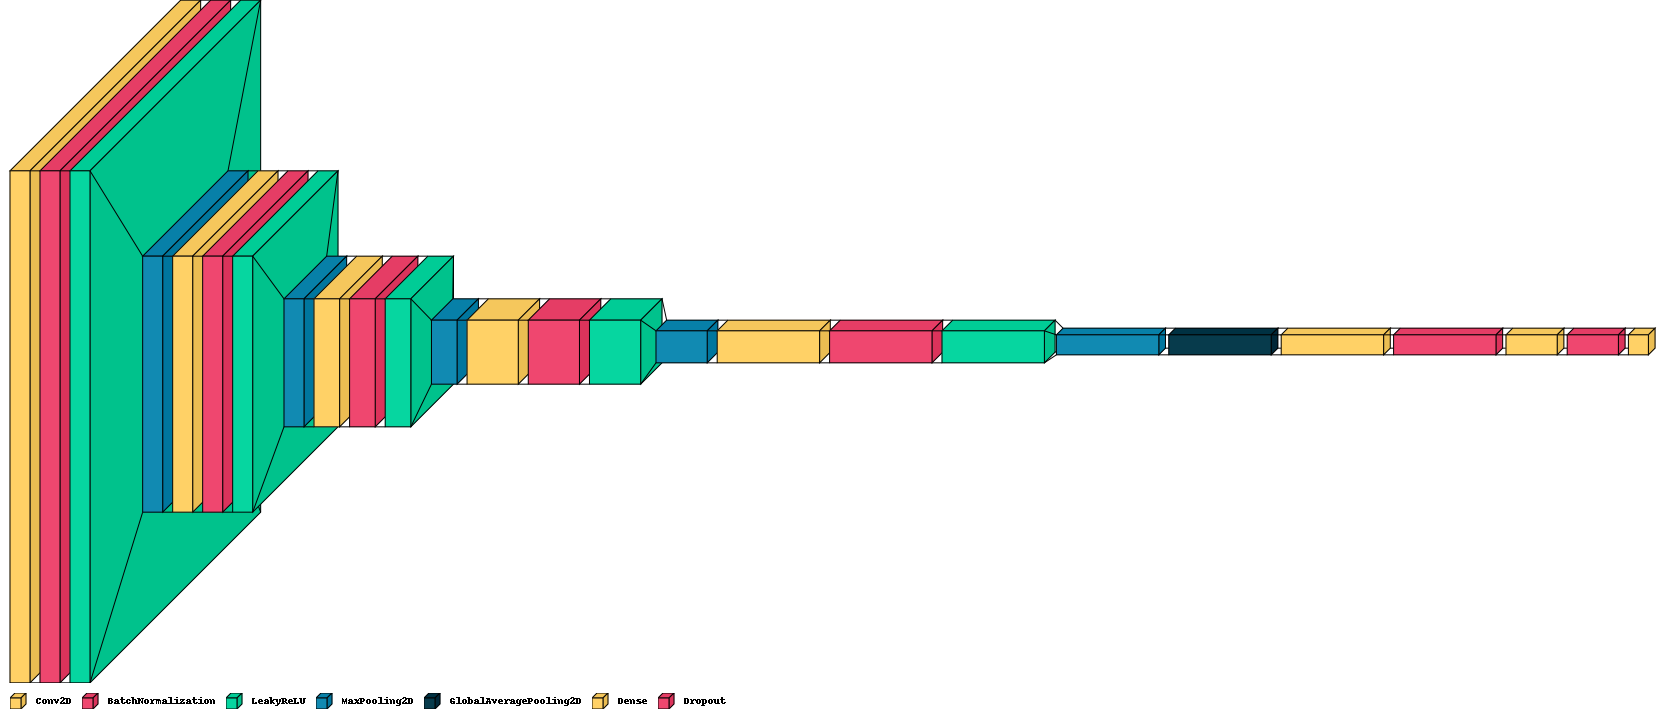

In [ ]:
visualkeras.layered_view(model,legend=True)

In [ ]:
#compile
model_4.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model_4.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 64)      1792      
                                                                 
 batch_normalization (Batch  (None, 128, 128, 64)      256       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 128, 128, 64)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 128)       73856     
                                                                 
 batch_normalization_1 (Bat  (None, 64, 64, 128)       5

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
training_history_4=model_4.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 182s 75ms/step - loss: 1.8109 - accuracy: 0.5676 - val_loss: 1.5926 - val_accuracy: 0.5864 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 161s 73ms/step - loss: 0.5060 - accuracy: 0.8446 - val_loss: 2.1287 - val_accuracy: 0.5266 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 168s 76ms/step - loss: 0.3268 - accuracy: 0.8995 - val_loss: 0.9667 - val_accuracy: 0.7520 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 161s 73ms/step - loss: 0.2822 - accuracy: 0.9179 - val_loss: 1.2578 - val_accuracy: 0.7126 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 162s 74ms/step - loss: 0.2137 - accuracy: 0.9381 - val_loss: 0.1782 - val_accuracy: 0.9430 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 160s 73ms/step - loss: 0.1832 - accuracy: 0.9494 - val_loss: 1.8708 - val_accuracy: 0.6967 - lr: 0.0010
Epoch 7/10
2197/2197 [==================

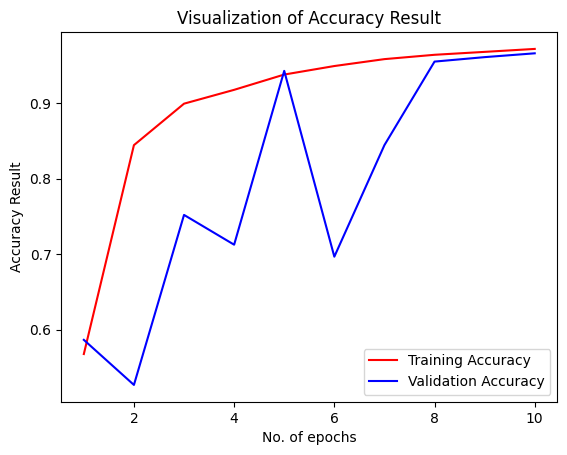

In [ ]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history_4.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history_4.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of epochs')
plt.ylabel('Accuracy Result')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [ ]:
# model evaluation on training set
train_loss,train_acc=model_4.evaluate(training_set)

2197/2197 [==============================] - 61s 27ms/step - loss: 0.1134 - accuracy: 0.9748


In [ ]:
print(train_loss,train_acc)

0.11342190206050873 0.9747776985168457


In [ ]:
# model evaluation on validation set
val_loss,val_acc=model_4.evaluate(validation_set)

550/550 [==============================] - 18s 32ms/step - loss: 0.1481 - accuracy: 0.9663


In [ ]:
print(val_loss,val_acc)

0.14813001453876495 0.9663100242614746


In [ ]:
y_pred = model.predict(test_set)

550/550 [==============================] - 18s 32ms/step


In [ ]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [ ]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [ ]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

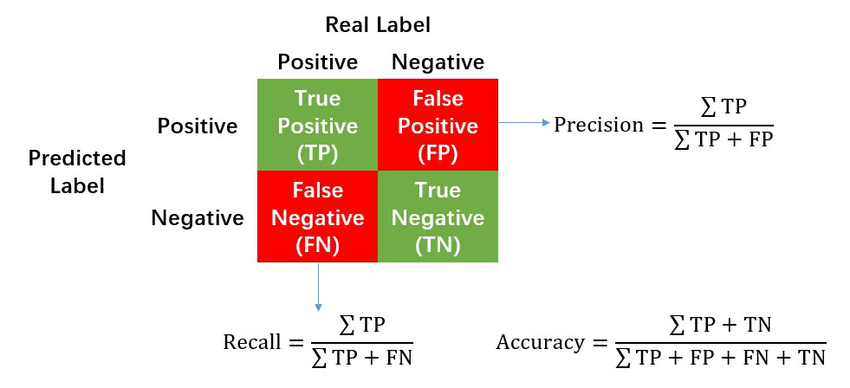

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.97      0.97       504
                                 Apple___Black_rot       0.98      0.99      0.98       497
                          Apple___Cedar_apple_rust       1.00      0.95      0.97       440
                                   Apple___healthy       0.95      0.96      0.96       502
                               Blueberry___healthy       0.89      0.99      0.94       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.95      0.97       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.99      0.93      0.96       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.98      0.

In [ ]:
cm = confusion_matrix(y_true,predicted_categories)
cm

array([[490,   5,   0, ...,   0,   0,   0],
       [  1, 492,   1, ...,   0,   0,   0],
       [  0,   1, 418, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 490,   0,   0],
       [  0,   0,   0, ...,   0, 445,   0],
       [  0,   0,   0, ...,   0,   0, 474]])

In [ ]:
tf.random.set_seed(42)

# Initialize the model_2
model_2 = Sequential()

# First Convolutional Block
model_2.add(Conv2D(filters=32, kernel_size=3, padding='same', input_shape=(128, 128, 3)))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))  # LeakyReLU applied as a separate layer
model_2.add(Conv2D(filters=32, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(MaxPooling2D(pool_size=2))
model_2.add(Dropout(0.3))

# Second Convolutional Block
model_2.add(Conv2D(filters=64, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(Conv2D(filters=64, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(MaxPooling2D(pool_size=2))
model_2.add(Dropout(0.3))

# Third Convolutional Block
model_2.add(Conv2D(filters=128, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(Conv2D(filters=128, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(MaxPooling2D(pool_size=2))
model_2.add(Dropout(0.3))

# Fourth Convolutional Block
model_2.add(Conv2D(filters=256, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(Conv2D(filters=256, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(MaxPooling2D(pool_size=2))
model_2.add(Dropout(0.3))

# Fifth Convolutional Block
model_2.add(Conv2D(filters=512, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(Conv2D(filters=512, kernel_size=3, padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.01))
model_2.add(MaxPooling2D(pool_size=2))
model_2.add(Dropout(0.3))

# Global Average Pooling Layer
model_2.add(GlobalAveragePooling2D())

# Fully Connected Layers
model_2.add(Dense(units=1024, activation='relu'))
model_2.add(Dropout(0.4))
model_2.add(Dense(units=512, activation='relu'))
model_2.add(Dropout(0.4))

# Output Layer
model_2.add(Dense(units=38, activation='softmax'))

In [ ]:
#compile
model_2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
model_2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_20 (Ba  (None, 128, 128, 32)      128       
 tchNormalization)                                               
                                                                 
 leaky_re_lu_20 (LeakyReLU)  (None, 128, 128, 32)      0         
                                                                 
 conv2d_21 (Conv2D)          (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_21 (Ba  (None, 128, 128, 32)      128       
 tchNormalization)                                               
                                                                 
 leaky_re_lu_21 (LeakyReLU)  (None, 128, 128, 32)     

In [ ]:
training_history=model_2.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 262s 113ms/step - loss: 2.1420 - accuracy: 0.3477 - val_loss: 2.6226 - val_accuracy: 0.3555 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 237s 108ms/step - loss: 1.1411 - accuracy: 0.6349 - val_loss: 0.8657 - val_accuracy: 0.7121 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 239s 109ms/step - loss: 0.7650 - accuracy: 0.7581 - val_loss: 0.8215 - val_accuracy: 0.7464 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 237s 108ms/step - loss: 0.5777 - accuracy: 0.8211 - val_loss: 1.2046 - val_accuracy: 0.6864 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 237s 108ms/step - loss: 0.4457 - accuracy: 0.8619 - val_loss: 0.4507 - val_accuracy: 0.8615 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 236s 107ms/step - loss: 0.3699 - accuracy: 0.8860 - val_loss: 0.4161 - val_accuracy: 0.8667 - lr: 0.0010
Epoch 7/10
2197/2197 [============

### Saving model

In [ ]:
model.save("trained_models(96.76).h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
model.save("trained_models.keras")

In [ ]:
training_history.history

{'loss': [3.0173020362854004,
  1.1574327945709229,
  0.9160500764846802,
  0.7597967982292175,
  0.6640800833702087,
  0.6198926568031311,
  0.5626389980316162,
  0.5357186198234558,
  0.5155366659164429,
  0.4717574715614319],
 'accuracy': [0.5663418173789978,
  0.8282238841056824,
  0.8850985169410706,
  0.9159684181213379,
  0.9332526922225952,
  0.9433388113975525,
  0.9531403183937073,
  0.958346962928772,
  0.961860716342926,
  0.9675937294960022],
 'val_loss': [3.404141426086426,
  1.390716314315796,
  1.2770744562149048,
  1.5445122718811035,
  0.6201587319374084,
  0.9909934997558594,
  0.6635951995849609,
  0.5530487895011902,
  0.7834376096725464,
  0.4411483705043793],
 'val_accuracy': [0.38436147570610046,
  0.7646824717521667,
  0.7731618285179138,
  0.7242772579193115,
  0.9293763041496277,
  0.8461757302284241,
  0.9288641214370728,
  0.9628955125808716,
  0.9076371788978577,
  0.9630093574523926],
 'lr': [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 

###Accuracy Visualization

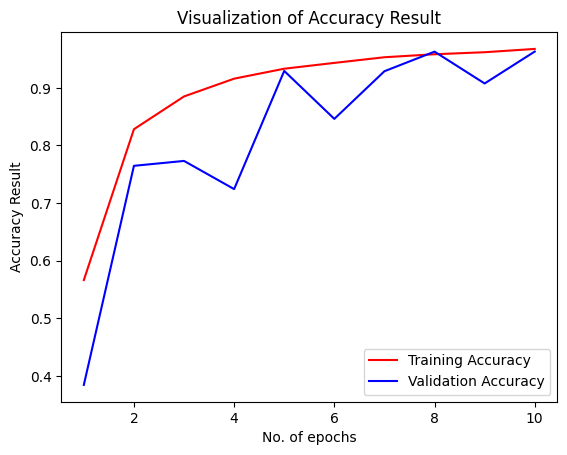

In [ ]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of epochs')
plt.ylabel('Accuracy Result')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

###Training Set

In [ ]:
test_set=tf.keras.utils.image_dataset_from_directory(
    '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [ ]:
y_pred = model.predict(test_set)

550/550 [==============================] - 15s 26ms/step


In [ ]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [ ]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [ ]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [ ]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix


In [ ]:
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98       504
                                 Apple___Black_rot       1.00      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.95      1.00      0.97       440
                                   Apple___healthy       0.93      0.99      0.96       502
                               Blueberry___healthy       0.98      0.97      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.98      1.00      0.99       421
                 Cherry_(including_sour)___healthy       0.97      1.00      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.90      0.92       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.98      0.

In [ ]:
cm = confusion_matrix(y_true,predicted_categories)
cm

array([[492,   0,   0, ...,   0,   0,   0],
       [  5, 486,   1, ...,   0,   0,   0],
       [  0,   1, 438, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 486,   0,   0],
       [  0,   0,   2, ...,   0, 435,   0],
       [  0,   0,   6, ...,   0,   0, 421]])

###Confusion Matrix Visualization

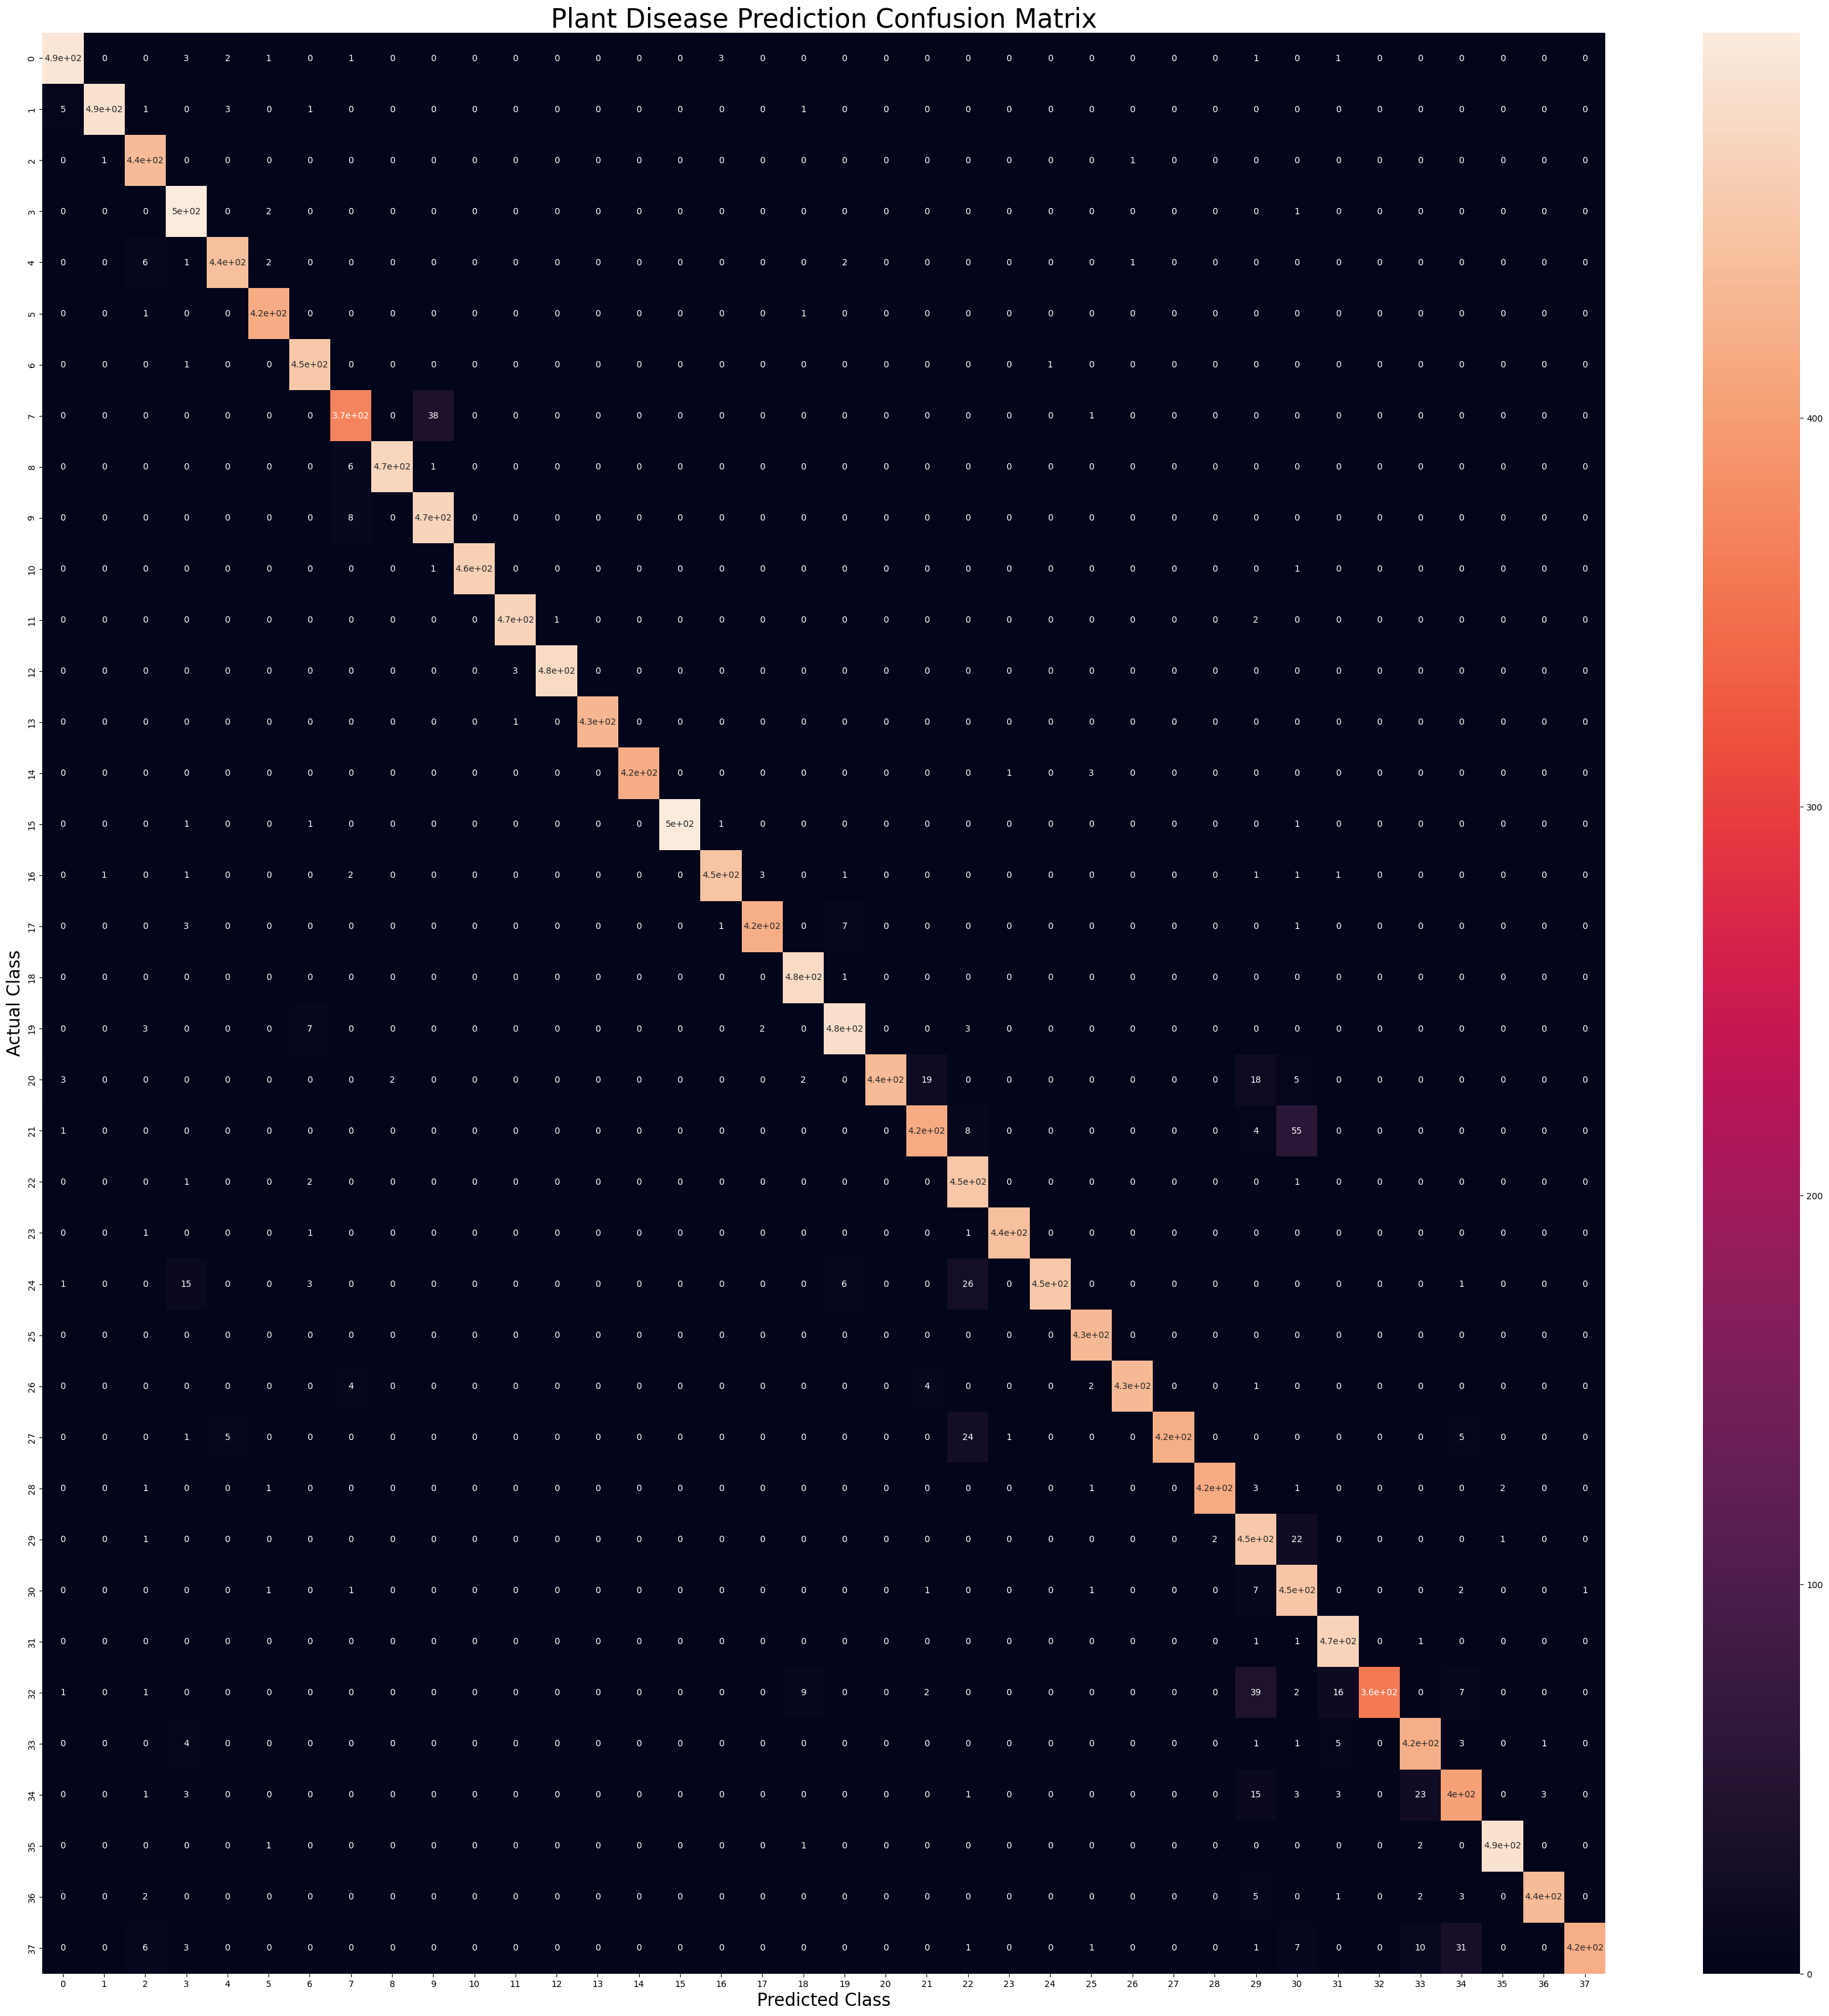

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel('Predicted Class',fontsize=20)
plt.ylabel('Actual Class',fontsize=20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize=30)
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50

In [ ]:
# Loading the ResNet50 without the top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
# Add custom layers
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(38, activation='softmax')
])

94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
#compile
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
training_history=model.fit(training_set,epochs=10,validation_data=validation_set,callbacks=[early_stopping, reduce_lr])

Epoch 1/10
2197/2197 [==============================] - 333s 131ms/step - loss: 0.7945 - accuracy: 0.7754 - val_loss: 0.8413 - val_accuracy: 0.7866 - lr: 0.0010
Epoch 2/10
2197/2197 [==============================] - 288s 131ms/step - loss: 0.2741 - accuracy: 0.9232 - val_loss: 0.8760 - val_accuracy: 0.7864 - lr: 0.0010
Epoch 3/10
2197/2197 [==============================] - 289s 131ms/step - loss: 0.2082 - accuracy: 0.9429 - val_loss: 0.5929 - val_accuracy: 0.8473 - lr: 0.0010
Epoch 4/10
2197/2197 [==============================] - 287s 130ms/step - loss: 0.1669 - accuracy: 0.9544 - val_loss: 0.2643 - val_accuracy: 0.9313 - lr: 0.0010
Epoch 5/10
2197/2197 [==============================] - 287s 131ms/step - loss: 0.1414 - accuracy: 0.9627 - val_loss: 0.2441 - val_accuracy: 0.9320 - lr: 0.0010
Epoch 6/10
2197/2197 [==============================] - 286s 130ms/step - loss: 0.1261 - accuracy: 0.9669 - val_loss: 0.1037 - val_accuracy: 0.9718 - lr: 0.0010
Epoch 7/10
2197/2197 [============

In [ ]:
# model evaluation on training set
train_loss,train_acc=model.evaluate(training_set)

2197/2197 [==============================] - 81s 37ms/step - loss: 1.5197 - accuracy: 0.7556


In [ ]:
y_pred = model.predict(test_set)

550/550 [==============================] - 22s 37ms/step


In [ ]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [ ]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [ ]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [ ]:
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.66      0.89      0.76       504
                                 Apple___Black_rot       0.85      0.95      0.90       497
                          Apple___Cedar_apple_rust       1.00      0.56      0.71       440
                                   Apple___healthy       0.30      0.96      0.45       502
                               Blueberry___healthy       0.44      1.00      0.61       454
          Cherry_(including_sour)___Powdery_mildew       0.79      0.81      0.80       421
                 Cherry_(including_sour)___healthy       1.00      0.01      0.01       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.89      0.86       410
                       Corn_(maize)___Common_rust_       1.00      0.90      0.95       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.77      0.

In [ ]:
model = tf.keras.models.load_model('my_model.h5')